<a href="https://colab.research.google.com/github/RubenAndreeB/Proyecto_TelecomX_Parte2/blob/main/Proyecto_TelecomX_Parte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

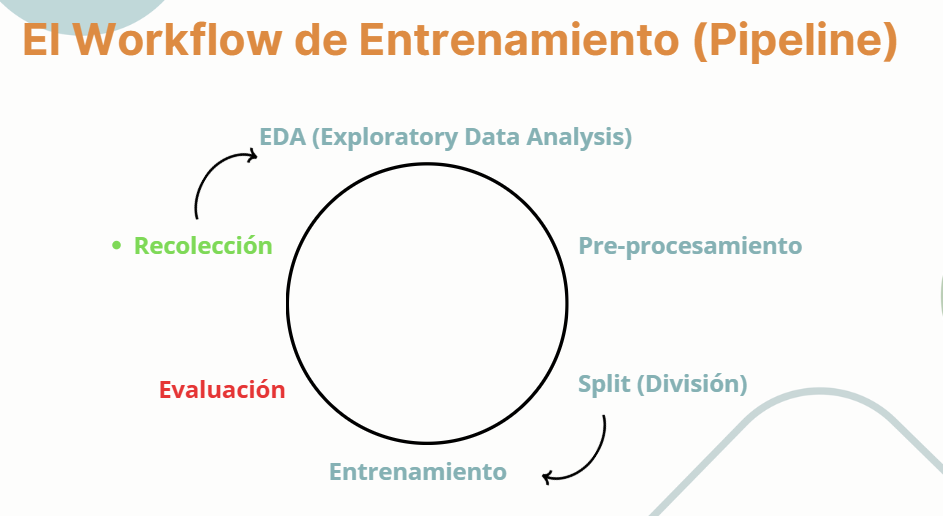

# Extraccion

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Configuración visual de Seaborn
sns.set_theme(style="whitegrid", palette="muted")

# Carga de datos
df = pd.read_csv('/content/datos_tratados.csv')
df.head()

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


In [17]:
df.columns

Index(['CustomerID', 'Churn', 'Gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'Tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'ChargesDaily', 'ChargesMonthly',
       'ChargesTotal'],
      dtype='object')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


# Preprocesamiento

In [19]:
df.isnull().sum()

,0
CustomerID,0
Churn,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


# EDA

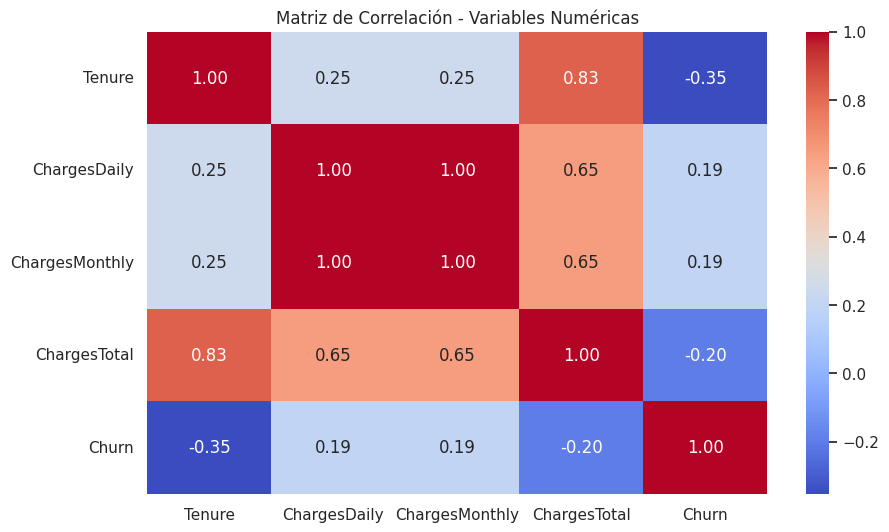

In [20]:
# 1. Crear una copia de los datos numéricos
df_numeric = df.select_dtypes(include=["int64", "float64"]).copy()

# 2. Codificar la variable objetivo
df_numeric["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# 3. Calcular la matriz
corr_matrix = df_numeric.corr()

# 4. Visualizar heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación - Variables Numéricas")
plt.show()

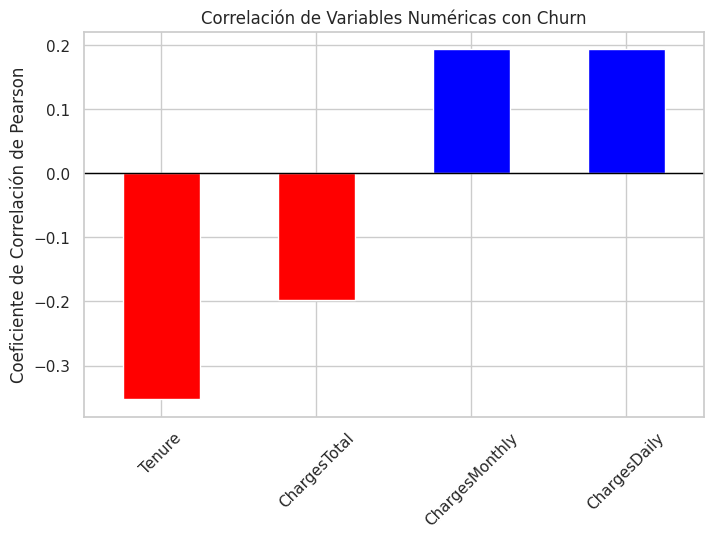

In [21]:
# Aislar la correlación con Churn, ordenar los valores y quitar el Churn vs Churn (que siempre es 1)
correlacion_churn = corr_matrix['Churn'].drop('Churn').sort_values()

# Graficar
plt.figure(figsize=(8, 5))
correlacion_churn.plot(kind='bar', color=correlacion_churn.apply(lambda x: 'red' if x < 0 else 'blue'))
plt.title('Correlación de Variables Numéricas con Churn')
plt.ylabel('Coeficiente de Correlación de Pearson')
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=45)
plt.show()

In [22]:
# ==============================================================================
# ANÁLISIS DE VARIABLES CATEGÓRICAS, PRUEBA CHI-CUADRADO Y LIMPIEZA
# ==============================================================================
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2
from IPython.display import display

# --- PASO 1: Identificar variables categóricas ---
print("1️⃣ IDENTIFICANDO VARIABLES CATEGÓRICAS...")
categorical_cols = df.select_dtypes(include=["object"]).columns
if "Churn" in categorical_cols:
    categorical_cols = categorical_cols.drop("Churn")
print(f"Variables a analizar: {list(categorical_cols)}\n")
print("-" * 60)

# --- PASO 2: Proporciones de Churn por categoría ---
print("\n2️⃣ ANALIZANDO PROPORCIONES DE CHURN POR CATEGORÍA...")
print("Mostrando el % de clientes que se quedan vs los que se van:\n")
for col in categorical_cols:
    print(f"🔹 Variable: {col}")
    # normalize="index" calcula el porcentaje por fila
    crosstab_result = (pd.crosstab(df[col], df["Churn"], normalize="index") * 100).round(2)
    display(crosstab_result)
    print("") # Espacio para separar
print("-" * 60)

# --- PASO 3: Preparación para la prueba estadística ---
print("\n3️⃣ PREPARANDO DATOS PARA LA PRUEBA ESTADÍSTICA...")
df_rank = df.copy() # Copia para no dañar el dataset original todavía
# Asegurar que el Churn sea 1 y 0
df_rank["Churn"] = df_rank["Churn"].map({"Yes": 1, "No": 0})

# Convertir texto a números temporalmente con LabelEncoder
le = LabelEncoder()
for col in categorical_cols:
    df_rank[col] = le.fit_transform(df_rank[col].astype(str))
print("✔️ Textos convertidos a números temporalmente.\n")
print("-" * 60)

# --- PASO 4: Ejecución de la prueba Chi-Cuadrado ---
print("\n4️⃣ EJECUTANDO PRUEBA CHI-CUADRADO...")
X_cat = df_rank[categorical_cols]
y = df_rank["Churn"]

# Aplicar Chi2
chi_scores, p_values = chi2(X_cat, y)

# Crear tabla de resultados ordenada por importancia
chi_df = pd.DataFrame({
    "Variable": categorical_cols,
    "Chi2 Score": chi_scores.round(2),
    "p-value": p_values
}).sort_values(by="Chi2 Score", ascending=False)

print("🏆 Ranking de Importancia (mayor Chi2 Score = mayor impacto en el Churn):")
display(chi_df)
print("\n" + "-" * 60)

# --- PASO 5: Decisión y limpieza automática ---
print("\n5️⃣ RESULTADOS Y LIMPIEZA AUTOMÁTICA...")
# Si p-value es menor a 0.05, la variable SÍ importa
significant_vars = chi_df[chi_df["p-value"] < 0.05]["Variable"].tolist()
# Si p-value es mayor o igual a 0.05, la variable NO importa (es ruido)
non_significant_vars = chi_df[chi_df["p-value"] >= 0.05]["Variable"].tolist()

print(f"✅ Variables SIGNIFICATIVAS (Se conservan):")
print(f"   {significant_vars}\n")

print(f"🗑️ Variables NO significativas (Basura estadística):")
print(f"   {non_significant_vars if len(non_significant_vars) > 0 else 'Ninguna'}\n")

# Eliminar del DataFrame original (df) las que no sirven
if len(non_significant_vars) > 0:
    df = df.drop(columns=non_significant_vars)
    print(f"🚀 ¡ÉXITO! Las columnas {non_significant_vars} han sido eliminadas del dataset principal.")
else:
    print("🚀 ¡ÉXITO! Todas las variables demostraron ser útiles. No se eliminó ninguna.")

1️⃣ IDENTIFICANDO VARIABLES CATEGÓRICAS...
Variables a analizar: ['CustomerID', 'Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

------------------------------------------------------------

2️⃣ ANALIZANDO PROPORCIONES DE CHURN POR CATEGORÍA...
Mostrando el % de clientes que se quedan vs los que se van:

🔹 Variable: CustomerID


Churn,No,Yes
CustomerID,,
0002-ORFBO,100.0,0.0
0003-MKNFE,100.0,0.0
0004-TLHLJ,0.0,100.0
0011-IGKFF,0.0,100.0
0013-EXCHZ,0.0,100.0
...,...,...
9987-LUTYD,100.0,0.0
9992-RRAMN,0.0,100.0
9992-UJOEL,100.0,0.0



🔹 Variable: Gender


Churn,No,Yes
Gender,,
Female,73.08,26.92
Male,73.84,26.16



🔹 Variable: SeniorCitizen


...


🔹 Variable: PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11



------------------------------------------------------------

3️⃣ PREPARANDO DATOS PARA LA PRUEBA ESTADÍSTICA...
✔️ Textos convertidos a números temporalmente.

------------------------------------------------------------

4️⃣ EJECUTANDO PRUEBA CHI-CUADRADO...
🏆 Ranking de Importancia (mayor Chi2 Score = mayor impacto en el Churn):


,Variable,Chi2 Score,p-value
0,CustomerID,2516.97,0.000000e+00
14,Contract,1115.78,1.227941e-244
8,OnlineSecurity,147.30,6.761696e-34
11,TechSupport,135.56,2.490549e-31
2,SeniorCitizen,134.35,4.576959e-31
4,Dependents,133.04,8.876729e-31
15,PaperlessBilling,105.68,8.661987e-25
3,Partner,82.41,1.104764e-19
16,PaymentMethod,58.49,2.040933e-14
9,OnlineBackup,31.22,2.306541e-08



------------------------------------------------------------

5️⃣ RESULTADOS Y LIMPIEZA AUTOMÁTICA...
✅ Variables SIGNIFICATIVAS (Se conservan):
   ['CustomerID', 'Contract', 'OnlineSecurity', 'TechSupport', 'SeniorCitizen', 'Dependents', 'PaperlessBilling', 'Partner', 'PaymentMethod', 'OnlineBackup', 'DeviceProtection', 'StreamingTV', 'StreamingMovies', 'InternetService', 'MultipleLines']

🗑️ Variables NO significativas (Basura estadística):
   ['Gender', 'PhoneService']

🚀 ¡ÉXITO! Las columnas ['Gender', 'PhoneService'] han sido eliminadas del dataset principal.


# Split

In [23]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [25]:
# Aplicar One-Hot Encoding en treno
X_train = pd.get_dummies(X_train, drop_first=True)

# Aplicar en teste
X_test = pd.get_dummies(X_test, drop_first=True)

# Garantir que treno y teste tengan las mismas columnas
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [27]:
X_train.head()

,Tenure,ChargesDaily,ChargesMonthly,ChargesTotal,CustomerID_0003-MKNFE,CustomerID_0004-TLHLJ,CustomerID_0011-IGKFF,CustomerID_0013-EXCHZ,CustomerID_0013-MHZWF,CustomerID_0016-QLJIS,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3793,60,3.14,94.10,5475.90,False,False,False,False,False,False,...,False,False,False,True,False,False,True,True,False,False
3192,12,0.64,19.35,212.30,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
4922,2,2.68,80.45,137.10,False,False,False,False,False,False,...,True,False,False,False,False,False,True,False,True,False
3926,33,2.49,74.75,2453.30,False,False,False,False,False,False,...,True,False,True,True,True,False,False,True,False,False
3859,14,2.87,86.00,1164.05,False,False,False,False,False,False,...,False,True,False,False,False,False,True,False,False,True


In [28]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 3793 to 5679
Columns: 5655 entries, Tenure to PaymentMethod_Mailed check
dtypes: bool(5651), float64(3), int64(1)
memory usage: 30.6 MB


In [29]:
y_train.value_counts(normalize=True) * 100

,proportion
Churn,
No,73.464679
Yes,26.535321


# Entrenamiento

Modelo 1 - Regresion Logistica

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log_normal = log_model.predict(X_test)

print("Regresion logistica")
print(classification_report(y_test, y_pred_log_normal))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Regresion logistica
              precision    recall  f1-score   support

          No       0.84      0.89      0.87      1035
         Yes       0.64      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



Modelo 2 - Random Forest

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

          No       0.82      0.92      0.87      1035
         Yes       0.67      0.46      0.54       374

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409



In [32]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

          No       0.89      0.75      0.81      1035
         Yes       0.52      0.73      0.60       374

    accuracy                           0.75      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.79      0.75      0.76      1409



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Evaluacion

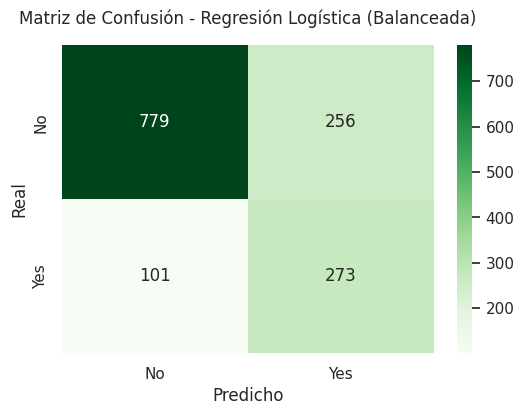

In [36]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Generar la matriz
cm = confusion_matrix(y_test, y_pred_log)

# Crear el gráfico
plt.figure(figsize=(6, 4))

# Usamos Seaborn con la paleta 'Greens' para diferenciarla del modelo anterior
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])

# Configuraciones de texto
plt.title("Matriz de Confusión - Regresión Logística (Balanceada)", pad=15)
plt.xlabel("Predicho")
plt.ylabel("Real")

# Mostrar el gráfico
plt.show()

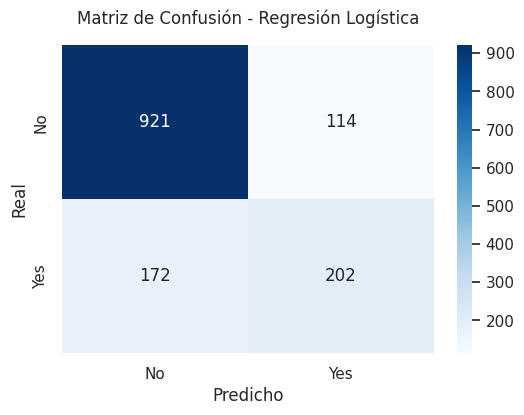

In [35]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_log_normal)

plt.figure(figsize=(6, 4))
# annot=True pone los números, fmt='d' asegura que sean enteros, cmap es el color
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])

plt.title("Matriz de Confusión - Regresión Logística", pad=15)
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

# 📊 Conclusiones y Plan de Acción Estratégico: Predicción de Churn
Tras el entrenamiento y evaluación de múltiples algoritmos de Machine Learning (Regresión Logística, Random Forest, SVM y KNN), hemos consolidado los hallazgos técnicos en un modelo de comportamiento del cliente. El consenso entre los diferentes algoritmos nos permite confirmar qué factores son los verdaderos impulsores del abandono (Churn) y diseñar estrategias precisas de retención.
## 1. Consenso Técnico: Análisis de Variables Críticas
Cada modelo aportó una perspectiva única (coeficientes de regresión, reducción de impureza de Gini en árboles, márgenes de decisión en SVM y distancias espaciales en KNN) . Al cruzar estos resultados, emergen tres pilares fundamentales que dictan la probabilidad de cancelación:
- Antigüedad (Tenure): Identificada unánimemente como la métrica más crítica de estabilidad. Los modelos demuestran una relación inversamente proporcional severa: el riesgo de abandono es crítico en los primeros meses y decae de forma exponencial una vez que el usuario supera la etapa de madurez en la plataforma.
- Estructura Contractual: El contrato mensual (Contract_Month-to-month) es el predictor de fuga más fuerte. Funciona como un separador clave en la frontera de decisión de los modelos, indicando que la falta de compromiso a largo plazo deja al cliente vulnerable a ofertas de la competencia. En contraste, los contratos de uno o dos años actúan como fuertes escudos de retención.
- Carga Financiera (ChargesTotal, ChargesMonthly, ChargesDaily): Los algoritmos detectan una alta sensibilidad al precio. Los cargos elevados, especialmente cuando se evalúan de forma mensual o diaria, incrementan consistentemente la probabilidad de Churn si el cliente no percibe un valor equivalente.
## 2. Hallazgos de Negocio y Áreas de Riesgo
Más allá de las métricas obvias, el análisis multivariable reveló insights estructurales sobre el servicio:
- La Paradoja de la Fibra Óptica: De manera contraintuitiva, los clientes con servicio de Fibra Óptica (InternetService_Fiber optic) muestran una mayor propensión al abandono frente a los usuarios de DSL. Esto sugiere una fuerte desconexión entre el costo premium del servicio y la experiencia real del usuario (posibles problemas de estabilidad o soporte técnico).
## 3. Estrategias de Retención Propuestas
Basándonos en la jerarquía de las variables detectadas, proponemos las siguientes acciones clave para mitigar el abandono:

🔹 Conversión Contractual

- Acción Recomendada: Diseñar campañas de upselling con beneficios exclusivos (upgrades o descuentos) para incentivar la migración de usuarios "Mes a Mes" a planes anuales.

- Justificación Técnica: El tipo de contrato posee el coeficiente de mayor impacto predictivo hacia el abandono en los modelos lineales.

🔹 Programa "Primeros Pasos" (Onboarding)

- Acción Recomendada: Implementar monitoreo proactivo, encuestas de satisfacción y soporte prioritario durante los primeros 6 meses del ciclo de vida del usuario.

- Justificación Técnica: La variable Tenure demuestra que la fuga de clientes se concentra masivamente en las etapas tempranas.

🔹 Optimización de Valor

- Acción Recomendada: Desplegar planes de fidelización o ajustes de tarifas personalizados para clientes identificados con estrés financiero (cargos altos y baja antigüedad).

- Justificación Técnica: Las variables de costo son predictores primarios y consistentes de cancelación en Random Forest y KNN.

🔹 Aseguramiento de Calidad

- Acción Recomendada: Lanzar una auditoría técnica inmediata sobre la infraestructura y atención al cliente de la división de Fibra Óptica.

- Justificación Técnica: El servicio de fibra es el único factor tecnológico que desplaza activamente a los usuarios hacia la región de "Churn" en la frontera de decisión de SVM.


# 💡 Conclusión Ejecutiva
La reducción del Churn no se logrará mediante esfuerzos aislados, sino transformando la relación con el usuario: de un esquema transaccional de corto plazo a un ecosistema de confianza basado en la retención temprana y la estabilidad de costos. Los modelos predictivos nos aseguran que si enfocamos los recursos en blindar la experiencia del cliente durante sus primeros meses y logramos transicionarlos hacia contratos a largo plazo, la curva de abandono se estabilizará de forma estructural.